# Stage 9: Cross-method Comparison Figures

This notebook reads Stage 9 outputs from `results/comparison/` and renders the required comparison figures.

Figures are saved to `results/comparison/figures/`.

In [ ]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 50)


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "results" / "comparison").exists() and (candidate / "src").exists():
            return candidate
    return start


ROOT = find_repo_root(Path.cwd())
COMPARISON_DIR = ROOT / "results" / "comparison"
FIGURES_DIR = COMPARISON_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

summary_paths = {
    "classifier": COMPARISON_DIR / "classifier_summary.parquet",
    "stability": COMPARISON_DIR / "stability_summary.parquet",
    "selection_curve": COMPARISON_DIR / "selection_frequency_curve.parquet",
    "enrichment": COMPARISON_DIR / "enrichment_summary.parquet",
    "simulation": COMPARISON_DIR / "simulation_summary.parquet",
    "full_data": COMPARISON_DIR / "full_data_summary.parquet",
    "full_data_overlap": COMPARISON_DIR / "full_data_overlap.parquet",
}

missing = [name for name, path in summary_paths.items() if not path.exists()]
if missing:
    raise FileNotFoundError(
        f"Missing Stage 9 summaries in {COMPARISON_DIR}: {missing}. Run scripts/06_aggregate_results.py first."
    )

classifier_summary = pd.read_parquet(summary_paths["classifier"])
stability_summary = pd.read_parquet(summary_paths["stability"])
selection_curve = pd.read_parquet(summary_paths["selection_curve"])
enrichment_summary = pd.read_parquet(summary_paths["enrichment"])
simulation_summary = pd.read_parquet(summary_paths["simulation"])
full_data_summary = pd.read_parquet(summary_paths["full_data"])
full_data_overlap = pd.read_parquet(summary_paths["full_data_overlap"])

print(f"Detected project root: {ROOT}")
print(f"Comparison directory: {COMPARISON_DIR}")
print(f"Figures directory: {FIGURES_DIR}")

In [ ]:
coverage = pd.DataFrame(
    {
        "table": [
            "classifier_summary",
            "stability_summary",
            "selection_frequency_curve",
            "enrichment_summary",
            "simulation_summary",
            "full_data_summary",
            "full_data_overlap",
        ],
        "rows": [
            len(classifier_summary),
            len(stability_summary),
            len(selection_curve),
            len(enrichment_summary),
            len(simulation_summary),
            len(full_data_summary),
            len(full_data_overlap),
        ],
    }
)

display(coverage)
display(stability_summary)
display(full_data_summary)
display(full_data_overlap)

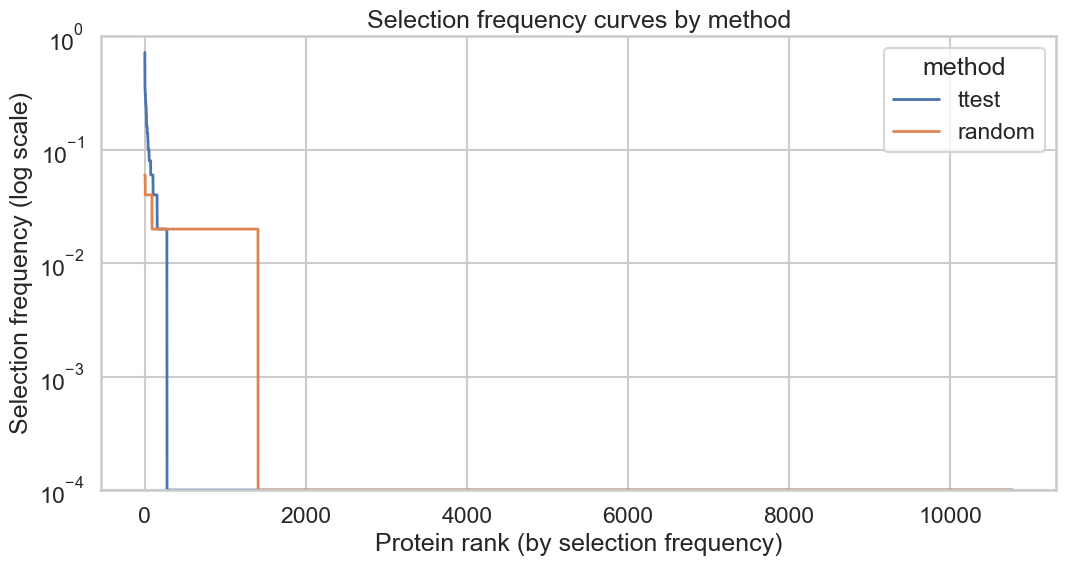

Saved: c:\Programmering\exjobb\MSc26_Proteomics\results\comparison\figures\selection_frequency_curves.png


In [3]:
curve_plot = selection_curve.copy()
curve_plot["frequency_plot"] = curve_plot["frequency"].clip(lower=1e-4)

plt.figure(figsize=(11, 6))
ax = sns.lineplot(
    data=curve_plot,
    x="rank",
    y="frequency_plot",
    hue="method",
    linewidth=2.0,
)
ax.set_yscale("log")
ax.set_xlabel("Protein rank (by selection frequency)")
ax.set_ylabel("Selection frequency (log scale)")
ax.set_title("Selection frequency curves by method")
ax.set_ylim(1e-4, 1.0)
ax.legend(title="method")

fig1_path = FIGURES_DIR / "selection_frequency_curves.png"
plt.tight_layout()
plt.savefig(fig1_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {fig1_path}")

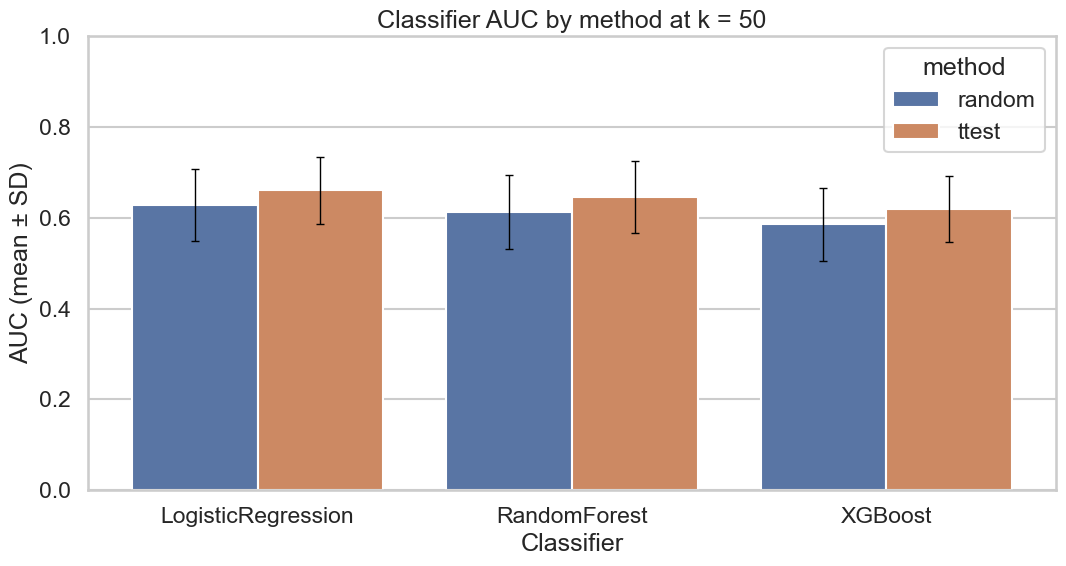

Saved: c:\Programmering\exjobb\MSc26_Proteomics\results\comparison\figures\classifier_auc_k50.png


In [17]:
auc_k50 = classifier_summary[classifier_summary["k"].astype(str) == "50"].copy()
if auc_k50.empty:
    raise ValueError("No rows with k='50' in classifier_summary.parquet")

auc_k50 = auc_k50.sort_values(["classifier", "method"], kind="mergesort").reset_index(drop=True)

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=auc_k50,
    x="classifier",
    y="auc_mean",
    hue="method",
    errorbar=None,
)

for patch, (_, row) in zip(ax.patches, auc_k50.iterrows()):
    x = patch.get_x() + patch.get_width() / 2.0
    y = patch.get_height()
    yerr = row["auc_sd"] if pd.notna(row["auc_sd"]) else 0.0
    ax.errorbar(x, y, yerr=yerr, color="black", capsize=3, linewidth=1)

ax.set_xlabel("Classifier")
ax.set_ylabel("AUC (mean ± SD)")
ax.set_title("Classifier AUC by method at k = 50")
ax.set_ylim(0.0, 1.0)
ax.legend(title="method")

fig2_path = FIGURES_DIR / "classifier_auc_k50.png"
plt.tight_layout()
plt.savefig(fig2_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {fig2_path}")

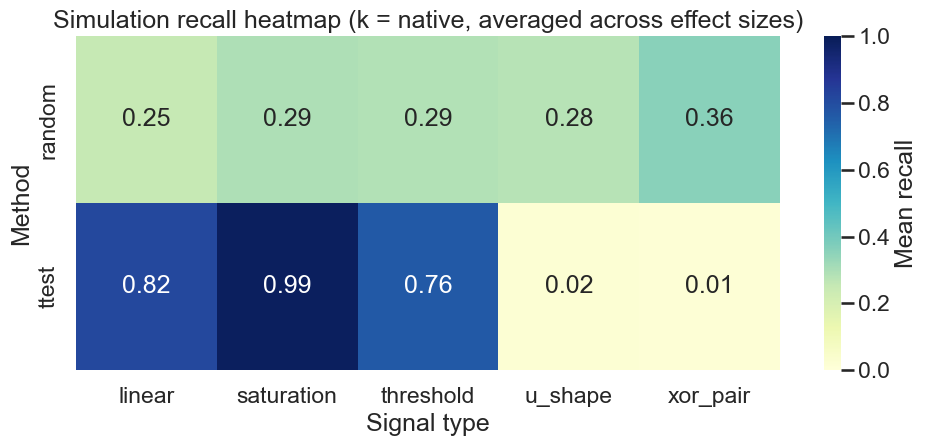

Saved: c:\Programmering\exjobb\MSc26_Proteomics\results\comparison\figures\simulation_recall_heatmap.png


In [5]:
sim_native = simulation_summary[simulation_summary["k"].astype(str) == "native"].copy()
if sim_native.empty:
    raise ValueError("No rows with k='native' in simulation_summary.parquet")

recall_heat = (
    sim_native.groupby(["method", "signal_type"], observed=False)
    .agg(recall_mean=("recall_mean", "mean"))
    .reset_index()
)

signal_order = ["linear", "saturation", "threshold", "u_shape", "xor_pair"]
method_order = sorted(recall_heat["method"].astype(str).unique().tolist())

heatmap_matrix = (
    recall_heat.pivot(index="method", columns="signal_type", values="recall_mean")
    .reindex(index=method_order, columns=signal_order)
)

plt.figure(figsize=(10, 4.8))
ax = sns.heatmap(
    heatmap_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0.0,
    vmax=1.0,
    cbar_kws={"label": "Mean recall"},
)
ax.set_xlabel("Signal type")
ax.set_ylabel("Method")
ax.set_title("Simulation recall heatmap (k = native, averaged across effect sizes)")

fig3_path = FIGURES_DIR / "simulation_recall_heatmap.png"
plt.tight_layout()
plt.savefig(fig3_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {fig3_path}")

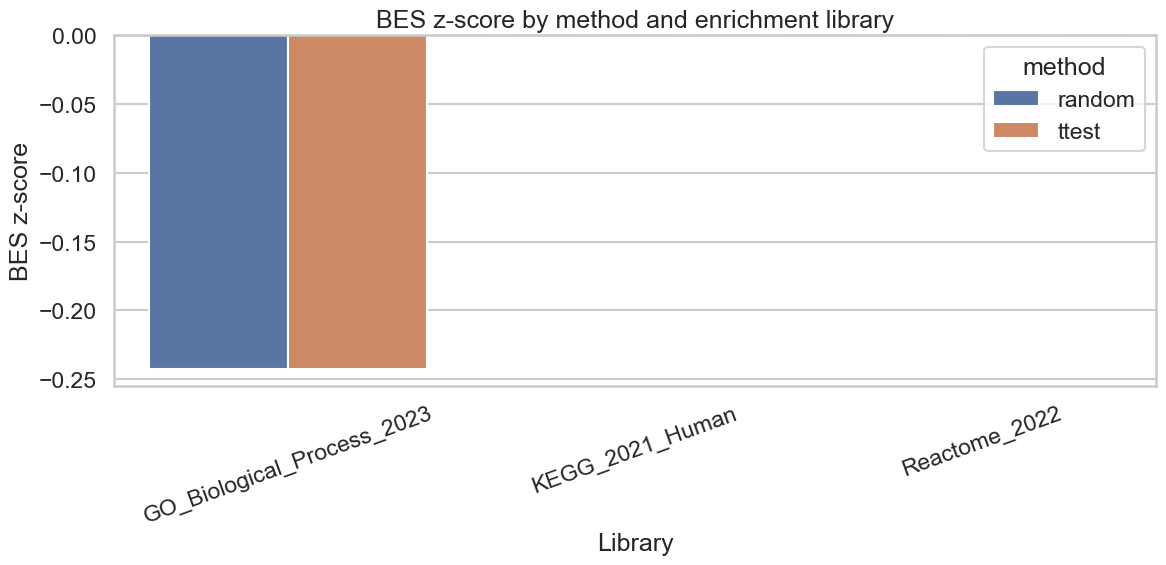

Saved: c:\Programmering\exjobb\MSc26_Proteomics\results\comparison\figures\bes_z_scores.png


In [6]:
enrichment_plot = enrichment_summary.copy()
enrichment_plot["bes_z"] = pd.to_numeric(enrichment_plot["bes_z"], errors="coerce")

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=enrichment_plot,
    x="library",
    y="bes_z",
    hue="method",
    errorbar=None,
)
ax.axhline(0.0, color="black", linewidth=1, linestyle="--")
ax.set_xlabel("Library")
ax.set_ylabel("BES z-score")
ax.set_title("BES z-score by method and enrichment library")
ax.legend(title="method")
ax.tick_params(axis="x", rotation=20)

fig4_path = FIGURES_DIR / "bes_z_scores.png"
plt.tight_layout()
plt.savefig(fig4_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {fig4_path}")

In [7]:
saved_figures = [
    FIGURES_DIR / "selection_frequency_curves.png",
    FIGURES_DIR / "classifier_auc_k50.png",
    FIGURES_DIR / "simulation_recall_heatmap.png",
    FIGURES_DIR / "bes_z_scores.png",
]

status = pd.DataFrame(
    {
        "figure": [p.name for p in saved_figures],
        "exists": [p.exists() for p in saved_figures],
        "path": [str(p) for p in saved_figures],
    }
)

display(status)

,figure,exists,path
0,selection_frequency_curves.png,True,c:\Programmering\exjobb\MSc26_Proteomics\resul...
1,classifier_auc_k50.png,True,c:\Programmering\exjobb\MSc26_Proteomics\resul...
2,simulation_recall_heatmap.png,True,c:\Programmering\exjobb\MSc26_Proteomics\resul...
3,bes_z_scores.png,True,c:\Programmering\exjobb\MSc26_Proteomics\resul...
